# Dasheng — ESC-50 Evaluation (k-NN & Linear Probing)

This notebook evaluates the pretrained `dasheng_base` model on [ESC-50](https://github.com/karoldvl/ESC-50) using:
- **k-Nearest Neighbours (k-NN)** — zero-parameter probe
- **Linear probing** — frozen backbone + logistic regression

Both experiments follow the official ESC-50 evaluation protocol:
- 5-fold cross-validation over folds 1–5
- Report mean accuracy ± std across folds

**Audio pipeline**: raw `.wav` → Dasheng front-end (MelSpec + AmplitudeToDB + BN) → Transformer → mean-pool tokens → feature vector (768-d)

## 0. Install dependencies (run once if needed)

## 1. Imports & configuration

In [9]:
import sys
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torchaudio.transforms as audio_transforms
from tqdm.auto import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print(f"torch : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

torch : 2.10.0+cu130
CUDA available: True
Using device: cuda


In [10]:
# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT  = Path(".").resolve()          # adjust if running from elsewhere
ESC50_ROOT = REPO_ROOT / "data" / "ESC-50-master"
AUDIO_DIR  = ESC50_ROOT / "audio"
META_CSV   = ESC50_ROOT / "meta" / "esc50.csv"

# ── Model ──────────────────────────────────────────────────────────────────
MODEL_NAME = "dasheng_base"   # or a local .pt path
TARGET_SR  = 16_000           # dasheng always expects 16 kHz

# ── k-NN ───────────────────────────────────────────────────────────────────
KNN_K = 10

# ── Linear probe ───────────────────────────────────────────────────────────
LR_MAX_ITER = 1000
LR_C        = 1.0   # inverse regularisation strength

assert AUDIO_DIR.exists(), f"Audio directory not found: {AUDIO_DIR}"
assert META_CSV.exists(),  f"Metadata CSV not found:   {META_CSV}"
print("Paths OK")

Paths OK


## 2. Load the pretrained Dasheng model

In [11]:
# Add local fork to path so we use OUR version of the code
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dasheng import dasheng_base

# Pass path= to skip download if you already have a local checkpoint:
# model = dasheng_base(path="/path/to/dasheng_base.pt")
model = dasheng_base()
model = model.eval().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded {MODEL_NAME}  ({n_params/1e6:.1f}M parameters)")

Loaded dasheng_base  (85.4M parameters)


## 3. Load ESC-50 metadata

In [12]:
meta = pd.read_csv(META_CSV)
print(meta.shape)
meta.head()

(2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [13]:
print(f"Classes : {meta['target'].nunique()}")
print(f"Folds   : {sorted(meta['fold'].unique())}")
print(f"Files   : {len(meta)}")
print(f"Category sample:\n{meta['category'].value_counts().head(10)}")

Classes : 50
Folds   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Files   : 2000
Category sample:
category
dog                40
chirping_birds     40
vacuum_cleaner     40
thunderstorm       40
door_wood_knock    40
can_opening        40
crow               40
clapping           40
fireworks          40
chainsaw           40
Name: count, dtype: int64


## 4. Feature extraction

For each clip we:
1. Load audio with `soundfile` (avoids torchaudio's torchcodec backend) and resample to 16 kHz with `torchaudio.transforms.Resample`
2. Convert stereo → mono
3. Pass through `model(waveform)` — returns `(1, T_patches, D)`
4. **Mean-pool** over the patch-time dimension → `(D,)` feature vector

In [14]:
@torch.inference_mode()
def extract_features(
    model: torch.nn.Module,
    meta: pd.DataFrame,
    audio_dir: Path,
    target_sr: int = 16_000,
    device: torch.device = torch.device("cpu"),
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns:
        features : (N, D)  float32 numpy array
        labels   : (N,)    int numpy array (target class index)
    """
    resamplers = {}  # cache resampler per source SR
    features, labels = [], []

    for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Extracting"):
        filepath = audio_dir / row["filename"]

        # Load audio with soundfile — avoids torchaudio's torchcodec backend
        # sf.read returns (T, channels) float64 by default
        wav_np, sr = sf.read(str(filepath), dtype="float32", always_2d=True)
        wav = torch.from_numpy(wav_np.T)  # (channels, T)

        # Mono
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)

        # Resample if needed (torchaudio.transforms.Resample is pure PyTorch)
        if sr != target_sr:
            if sr not in resamplers:
                resamplers[sr] = audio_transforms.Resample(sr, target_sr)
            wav = resamplers[sr](wav)

        # (1, T) — batch of 1
        wav = wav.to(device)

        # Forward pass → (1, N_patches, D)
        out = model(wav)

        # Mean-pool over patch tokens → (D,)
        feat = out.mean(dim=1).squeeze(0).cpu().float().numpy()

        features.append(feat)
        labels.append(row["target"])

    return np.stack(features), np.array(labels)


features, labels = extract_features(model, meta, AUDIO_DIR, TARGET_SR, DEVICE)
print(f"Features shape : {features.shape}")
print(f"Labels   shape : {labels.shape}")

Extracting: 100%|██████████| 2000/2000 [01:29<00:00, 22.27it/s]

Features shape : (2000, 768)
Labels   shape : (2000,)


## 5. Cross-validated evaluation (5-fold)

We follow the ESC-50 protocol: use each fold once as test set, train on the remaining 4 folds.

In [15]:
folds = meta["fold"].values
fold_ids = sorted(np.unique(folds))

knn_accs  = []
lr_accs   = []

for test_fold in fold_ids:
    train_mask = folds != test_fold
    test_mask  = folds == test_fold

    X_train, y_train = features[train_mask], labels[train_mask]
    X_test,  y_test  = features[test_mask],  labels[test_mask]

    # ── k-NN ───────────────────────────────────────────────────────────────
    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=KNN_K, metric="cosine")),
    ])
    knn_pipe.fit(X_train, y_train)
    knn_pred = knn_pipe.predict(X_test)
    knn_acc  = accuracy_score(y_test, knn_pred)
    knn_accs.append(knn_acc)

    # ── Linear probe ───────────────────────────────────────────────────────
    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(C=LR_C, max_iter=LR_MAX_ITER, solver="lbfgs")),
    ])
    lr_pipe.fit(X_train, y_train)
    lr_pred = lr_pipe.predict(X_test)
    lr_acc  = accuracy_score(y_test, lr_pred)
    lr_accs.append(lr_acc)

    print(f"Fold {test_fold} — k-NN: {knn_acc*100:.1f}%   LR: {lr_acc*100:.1f}%")

print()
print(f"k-NN  (k={KNN_K}) : {np.mean(knn_accs)*100:.2f}% ± {np.std(knn_accs)*100:.2f}%")
print(f"Linear probe     : {np.mean(lr_accs)*100:.2f}% ± {np.std(lr_accs)*100:.2f}%")

Fold 1 — k-NN: 73.2%   LR: 87.5%
Fold 2 — k-NN: 74.0%   LR: 90.5%
Fold 3 — k-NN: 74.0%   LR: 86.0%
Fold 4 — k-NN: 79.2%   LR: 91.5%
Fold 5 — k-NN: 76.0%   LR: 86.8%

k-NN  (k=10) : 75.30% ± 2.18%
Linear probe     : 88.45% ± 2.16%


## 6. Confusion matrix (linear probe — fold 5 as test)

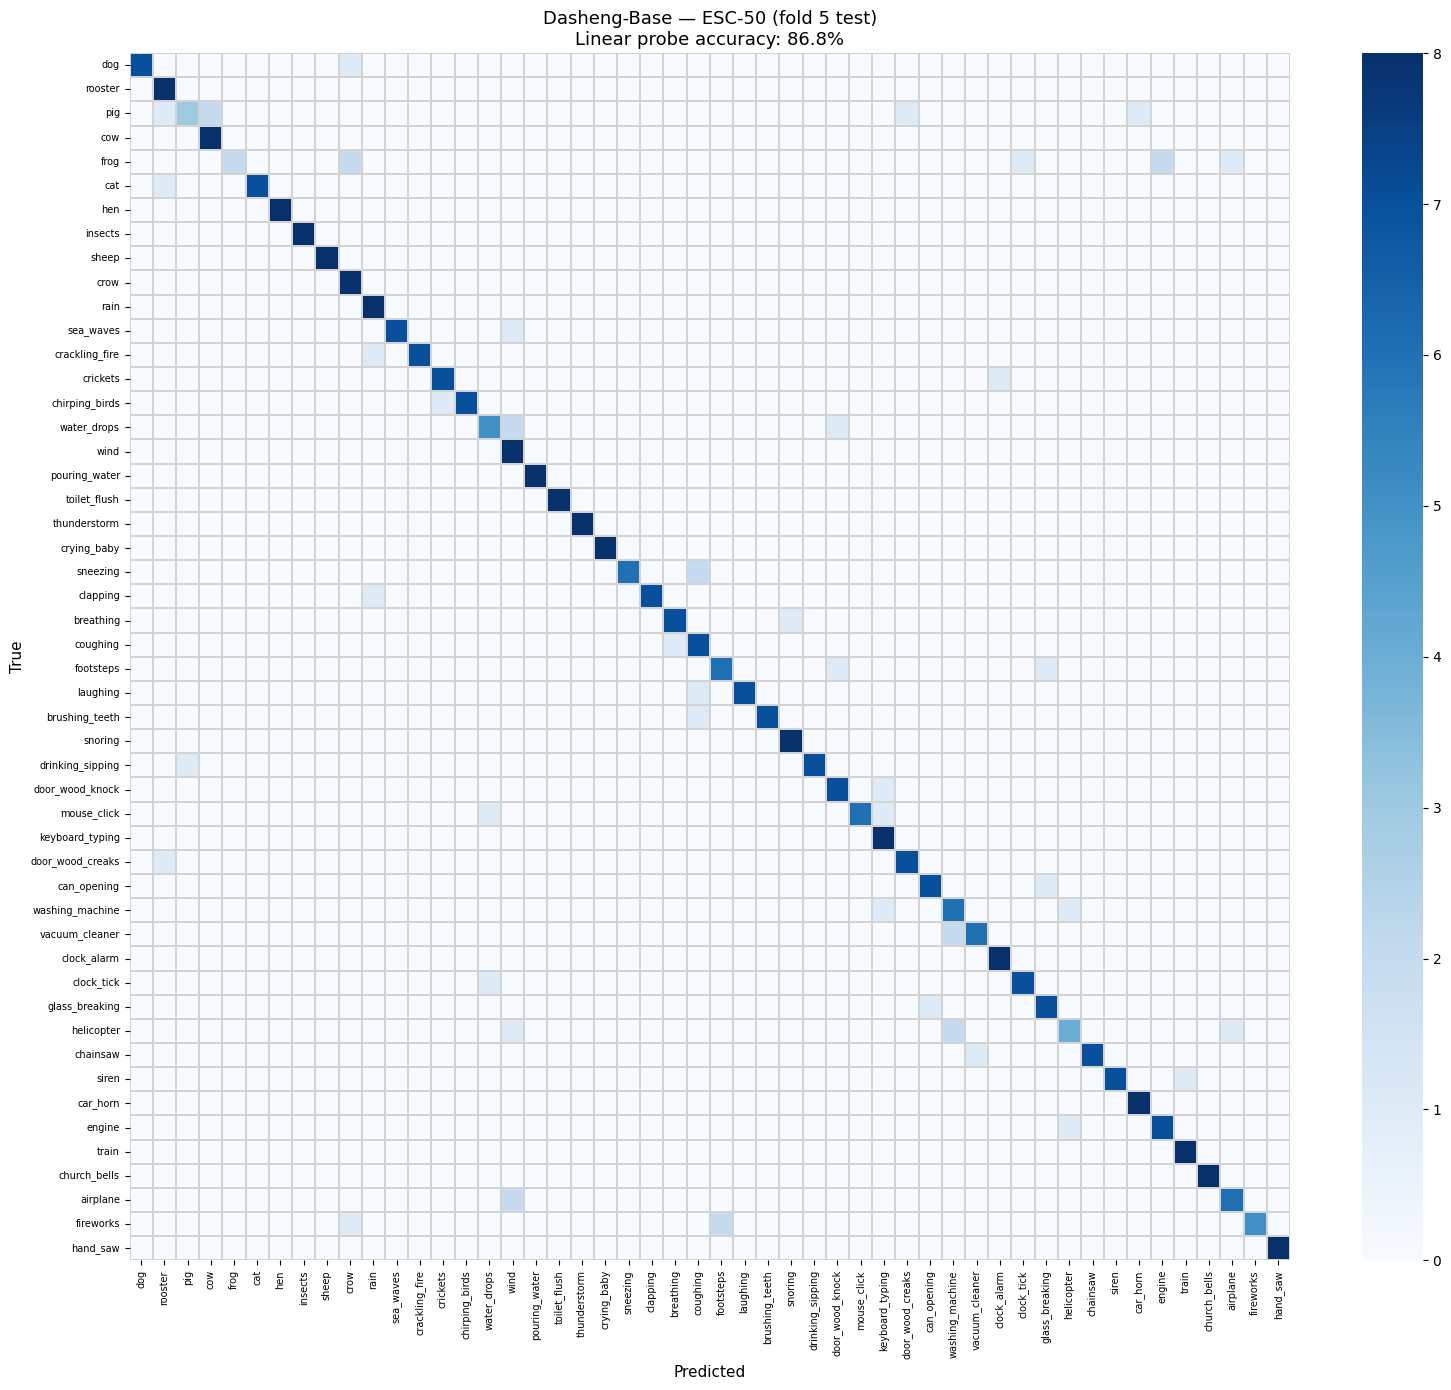

In [16]:
# Re-fit on folds 1–4, test on fold 5 for the confusion matrix
CONF_TEST_FOLD = 5

train_mask = folds != CONF_TEST_FOLD
test_mask  = folds == CONF_TEST_FOLD

class_names = (
    meta[["target", "category"]]
    .drop_duplicates()
    .sort_values("target")["category"]
    .tolist()
)

lr_pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(C=LR_C, max_iter=LR_MAX_ITER, solver="lbfgs")),
])
lr_pipe_final.fit(features[train_mask], labels[train_mask])
y_pred_final = lr_pipe_final.predict(features[test_mask])

cm = confusion_matrix(labels[test_mask], y_pred_final)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm,
    ax=ax,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    annot=False,
    fmt="d",
    linewidths=0.3,
    linecolor="lightgrey",
)
ax.set_title(
    f"Dasheng-Base — ESC-50 (fold {CONF_TEST_FOLD} test)\n"
    f"Linear probe accuracy: {accuracy_score(labels[test_mask], y_pred_final)*100:.1f}%",
    fontsize=13,
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig("esc50_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Per-class accuracy breakdown

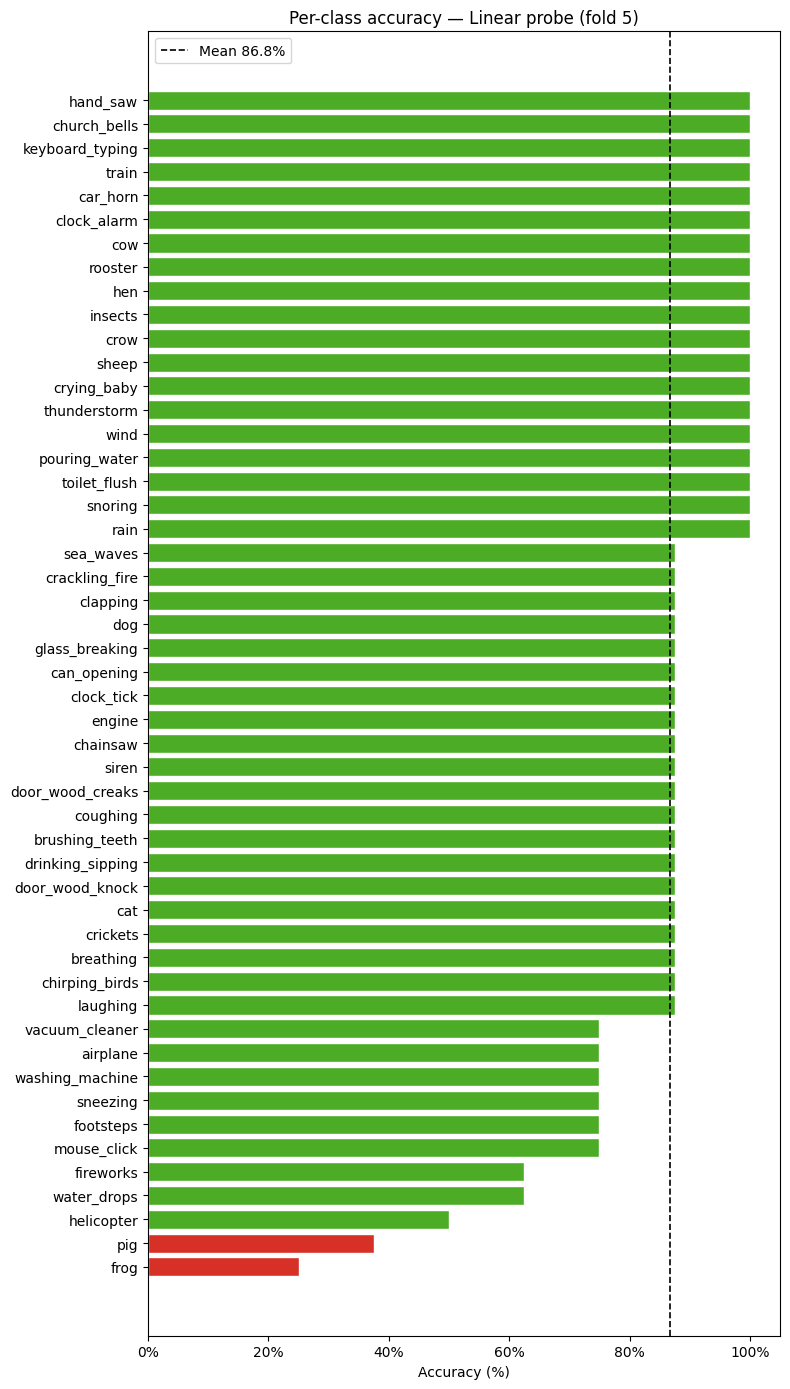


Bottom-5 classes:
   category  accuracy
       frog     0.250
        pig     0.375
 helicopter     0.500
water_drops     0.625
  fireworks     0.625

Top-5 classes:
       category  accuracy
       car_horn       1.0
          train       1.0
keyboard_typing       1.0
   church_bells       1.0
       hand_saw       1.0


In [17]:
y_true_fold = labels[test_mask]
per_class_acc = [
    accuracy_score(y_true_fold[y_true_fold == c],
                   y_pred_final[y_true_fold == c])
    for c in range(len(class_names))
]

per_class_df = pd.DataFrame({
    "category": class_names,
    "accuracy": per_class_acc,
}).sort_values("accuracy")

fig, ax = plt.subplots(figsize=(8, 14))
bars = ax.barh(
    per_class_df["category"],
    per_class_df["accuracy"] * 100,
    color=["#d73027" if a < 0.5 else "#4dac26" for a in per_class_df["accuracy"]],
    edgecolor="white",
)
ax.axvline(np.mean(per_class_acc) * 100, color="black", linestyle="--",
           linewidth=1.2, label=f"Mean {np.mean(per_class_acc)*100:.1f}%")
ax.set_xlabel("Accuracy (%)")
ax.set_title(f"Per-class accuracy — Linear probe (fold {CONF_TEST_FOLD})")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig("esc50_per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBottom-5 classes:")
print(per_class_df.head(5).to_string(index=False))
print("\nTop-5 classes:")
print(per_class_df.tail(5).to_string(index=False))

## 8. Summary

In [18]:
summary = pd.DataFrame({
    "Method": [f"k-NN (k={KNN_K}, cosine)", "Linear probe (LR)"],
    "Mean acc (%)": [
        f"{np.mean(knn_accs)*100:.2f}",
        f"{np.mean(lr_accs)*100:.2f}",
    ],
    "Std (%)": [
        f"{np.std(knn_accs)*100:.2f}",
        f"{np.std(lr_accs)*100:.2f}",
    ],
    "Per-fold accs (%)": [
        ", ".join(f"{a*100:.1f}" for a in knn_accs),
        ", ".join(f"{a*100:.1f}" for a in lr_accs),
    ],
})
print("=" * 65)
print("  Dasheng-Base — ESC-50 (5-fold cross-validation)")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)
print(f"  Feature dim : {features.shape[1]}")
print(f"  Model       : {MODEL_NAME}")
print(f"  Device      : {DEVICE}")

  Dasheng-Base — ESC-50 (5-fold cross-validation)
             Method Mean acc (%) Std (%)            Per-fold accs (%)
k-NN (k=10, cosine)        75.30    2.18 73.2, 74.0, 74.0, 79.2, 76.0
  Linear probe (LR)        88.45    2.16 87.5, 90.5, 86.0, 91.5, 86.8
  Feature dim : 768
  Model       : dasheng_base
  Device      : cuda
